# SPY Regime HMM

Replace the SPY 200-SMA + 20d-vol regime mask used in `ensemble_pipeline.py` lines 222-230 with a 3-state Gaussian HMM (bull / chop / bear) trained on SPY log-returns and 20-day realized vol.

**Design choices** (confirmed with user):
- **3 states** so we can scale exposure later (1.0 / 0.5 / 0.0) instead of binary on/off
- **Features:** SPY daily log-return + 20-day realized vol (2-D Gaussian emissions)
- **No lookahead:** expanding-window refit monthly, online forward-filtered state probabilities P(s_t | obs_{1..t})
- **Standalone:** no changes to the live pipeline yet — we benchmark vs the SMA mask and decide afterwards

**Why a from-scratch HMM:** `hmmlearn` wheel fails to build in this venv. Gaussian HMM with forward-backward + EM is ~150 lines and gives us full control over the filtered/smoothed distinction (critical for avoiding lookahead).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.special import logsumexp

np.random.seed(0)
plt.rcParams['figure.figsize'] = (12, 4)

## 1. Load SPY data

Local pickle has no SPY, so pull from yfinance once and cache.

In [2]:
import os
CACHE = 'spy_cache.parquet'
if os.path.exists(CACHE):
    spy = pd.read_parquet(CACHE)
else:
    spy = yf.download('SPY', start='2005-01-01', auto_adjust=False, progress=False)
    if isinstance(spy.columns, pd.MultiIndex):
        spy.columns = spy.columns.get_level_values(0)
    spy.to_parquet(CACHE)

px = spy['Adj Close'].astype(float)
px.index = pd.to_datetime(px.index)
print(px.index.min(), '->', px.index.max(), len(px), 'days')
px.tail()

2005-01-03 00:00:00 -> 2026-05-18 00:00:00 5377 days


Date
2026-05-12    738.179993
2026-05-13    742.309998
2026-05-14    748.169983
2026-05-15    739.169983
2026-05-18    736.390015
Name: Adj Close, dtype: float64

## 2. Build features

Two observation channels per day:
1. Log return $r_t = \log(P_t / P_{t-1})$
2. 20-day rolling std of log returns (realized vol proxy)

We z-score both before fitting so EM doesn't fight scale mismatches.

In [3]:
ret = np.log(px / px.shift(1))
rv = ret.rolling(20).std()
feats = pd.concat({'ret': ret, 'rv': rv}, axis=1).dropna()
print(feats.shape)
feats.tail()

(5357, 2)


,ret,rv
Date,,
2026-05-12,-0.001516,0.006215
2026-05-13,0.005579,0.006143
2026-05-14,0.007863,0.006239
2026-05-15,-0.012102,0.006756
2026-05-18,-0.003768,0.006823


## 3. Gaussian HMM (from scratch)

Standard discrete-time HMM with $K$ states and diagonal-covariance Gaussian emissions on $D$ features.

- $\pi$: initial state distribution `(K,)`
- $A$: transition matrix `(K, K)` with $A_{ij} = P(s_{t+1}=j \mid s_t=i)$
- $\mu, \sigma$: emission parameters `(K, D)`

Trained with EM (Baum-Welch). All recursions in log-space for stability.

In [4]:
def _log_gauss(X, mu, sigma):
    # X: (T,D), mu: (K,D), sigma: (K,D) -> (T,K) log p(x_t | s=k)
    T, D = X.shape
    K = mu.shape[0]
    diff = X[:, None, :] - mu[None, :, :]
    inv_var = 1.0 / (sigma ** 2)
    log_norm = -0.5 * (D * np.log(2 * np.pi) + np.sum(2 * np.log(sigma), axis=1))
    quad = -0.5 * np.sum((diff ** 2) * inv_var[None, :, :], axis=2)
    return log_norm[None, :] + quad

def _forward(log_pi, log_A, log_B):
    T, K = log_B.shape
    log_alpha = np.empty((T, K))
    log_alpha[0] = log_pi + log_B[0]
    for t in range(1, T):
        log_alpha[t] = log_B[t] + logsumexp(log_alpha[t-1][:, None] + log_A, axis=0)
    return log_alpha

def _backward(log_A, log_B):
    T, K = log_B.shape
    log_beta = np.zeros((T, K))
    for t in range(T - 2, -1, -1):
        log_beta[t] = logsumexp(log_A + log_B[t+1][None, :] + log_beta[t+1][None, :], axis=1)
    return log_beta

class GaussianHMM:
    def __init__(self, n_states=3, n_iter=50, tol=1e-4, min_sigma=1e-4, seed=0):
        self.K = n_states
        self.n_iter = n_iter
        self.tol = tol
        self.min_sigma = min_sigma
        self.seed = seed

    def _init(self, X):
        # init means by quantile slicing of first feature (return) for stable bull/chop/bear init
        order = np.argsort(X[:, 0])
        chunks = np.array_split(order, self.K)
        self.mu = np.stack([X[c].mean(axis=0) for c in chunks])
        self.sigma = np.stack([X[c].std(axis=0) + self.min_sigma for c in chunks])
        self.pi = np.full(self.K, 1.0 / self.K)
        self.A = np.full((self.K, self.K), 0.05 / (self.K - 1))
        np.fill_diagonal(self.A, 0.95)  # sticky prior keeps regimes from flickering daily

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self._init(X)
        prev_ll = -np.inf
        for it in range(self.n_iter):
            log_pi, log_A = np.log(self.pi + 1e-300), np.log(self.A + 1e-300)
            log_B = _log_gauss(X, self.mu, self.sigma)
            log_alpha = _forward(log_pi, log_A, log_B)
            log_beta = _backward(log_A, log_B)
            ll = logsumexp(log_alpha[-1])
            log_gamma = log_alpha + log_beta - ll
            gamma = np.exp(log_gamma)
            log_xi = (log_alpha[:-1, :, None] + log_A[None, :, :]
                       + log_B[1:, None, :] + log_beta[1:, None, :]) - ll
            xi = np.exp(log_xi)
            self.pi = gamma[0] / gamma[0].sum()
            self.A = xi.sum(axis=0) / xi.sum(axis=(0, 2))[:, None]
            Nk = gamma.sum(axis=0)[:, None]
            self.mu = (gamma.T @ X) / Nk
            diff2 = (X[:, None, :] - self.mu[None, :, :]) ** 2
            self.sigma = np.sqrt((gamma[:, :, None] * diff2).sum(axis=0) / Nk) + self.min_sigma
            if abs(ll - prev_ll) < self.tol:
                break
            prev_ll = ll
        self.log_likelihood_ = ll
        self.n_iter_ = it + 1
        return self

    def filter(self, X):
        # Online filtered P(s_t | obs_{1..t}) — no lookahead
        X = np.asarray(X, dtype=float)
        log_pi, log_A = np.log(self.pi + 1e-300), np.log(self.A + 1e-300)
        log_B = _log_gauss(X, self.mu, self.sigma)
        log_alpha = _forward(log_pi, log_A, log_B)
        return np.exp(log_alpha - logsumexp(log_alpha, axis=1, keepdims=True))

    def smooth(self, X):
        # Smoothed P(s_t | obs_{1..T}) — uses future info, research only
        X = np.asarray(X, dtype=float)
        log_pi, log_A = np.log(self.pi + 1e-300), np.log(self.A + 1e-300)
        log_B = _log_gauss(X, self.mu, self.sigma)
        log_alpha = _forward(log_pi, log_A, log_B)
        log_beta = _backward(log_A, log_B)
        log_gamma = log_alpha + log_beta
        return np.exp(log_gamma - logsumexp(log_gamma, axis=1, keepdims=True))

### 3a. Sanity fit on full sample (smoothed) — EDA only

Do the learned states correspond to recognisable bull / chop / bear behaviour?

In [5]:
X_all = feats.values
mu_s, sd_s = X_all.mean(axis=0), X_all.std(axis=0)
X_std = (X_all - mu_s) / sd_s

hmm_eda = GaussianHMM(n_states=3, n_iter=80, seed=0).fit(X_std)
print(f'converged in {hmm_eda.n_iter_} iters, ll={hmm_eda.log_likelihood_:.1f}')

mu_orig = hmm_eda.mu * sd_s + mu_s
summary = pd.DataFrame(mu_orig, columns=['mean_ret', 'mean_rv'])
summary['ann_ret'] = summary['mean_ret'] * 252
summary['ann_vol'] = summary['mean_rv'] * np.sqrt(252)
summary['stay_prob'] = np.diag(hmm_eda.A)
summary

converged in 18 iters, ll=-7386.4


,mean_ret,mean_rv,ann_ret,ann_vol,stay_prob
0,-0.000647,0.023312,-0.163036,0.370064,0.978732
1,0.000667,0.005610,0.168098,0.089054,0.980050
2,0.000456,0.010484,0.114888,0.166432,0.971579


state -> label: {np.int64(0): 'bear', np.int64(2): 'chop', np.int64(1): 'bull'}


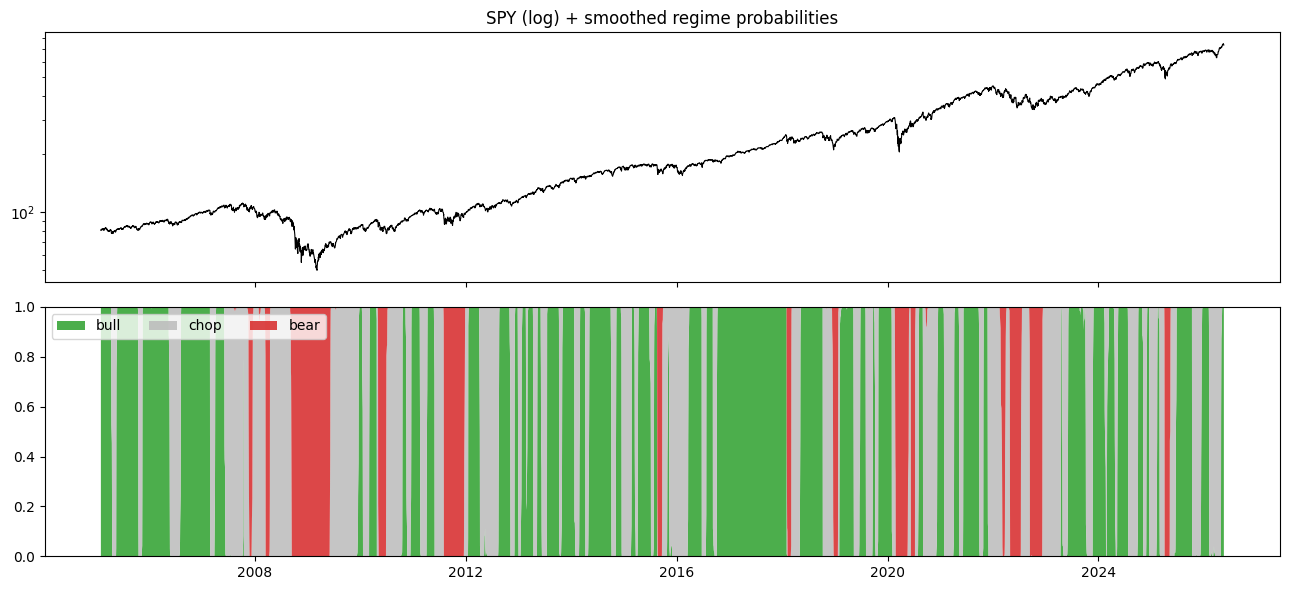

In [6]:
order = np.argsort(summary['ann_ret'].values)
labels = {order[0]: 'bear', order[1]: 'chop', order[2]: 'bull'}
print('state -> label:', labels)

gamma_smooth = hmm_eda.smooth(X_std)
smooth_df = pd.DataFrame(gamma_smooth, index=feats.index,
                          columns=[labels[k] for k in range(3)])[['bull', 'chop', 'bear']]

fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
a1.plot(px.loc[smooth_df.index], color='k', lw=0.8)
a1.set_yscale('log'); a1.set_title('SPY (log) + smoothed regime probabilities')
a2.stackplot(smooth_df.index, smooth_df['bull'], smooth_df['chop'], smooth_df['bear'],
              labels=['bull', 'chop', 'bear'], colors=['#2ca02c', '#bbbbbb', '#d62728'], alpha=0.85)
a2.legend(loc='upper left', ncol=3); a2.set_ylim(0, 1)
plt.tight_layout()

## 4. Expanding-window refit with online filtered probabilities

For each monthly refit date $t_r$:
1. Fit HMM on `feats[:t_r]` standardized using stats from `feats[:t_r]` (no future leakage)
2. Apply `.filter(...)` up to the next refit date — forward filter is causal
3. Label states by `ann_ret` ordering so labels stay consistent across refits

First fit uses 3 years of warmup.

In [7]:
WARMUP_YEARS = 3
refit_dates = feats.resample('ME').last().index
first_refit = feats.index[feats.index >= feats.index[0] + pd.DateOffset(years=WARMUP_YEARS)][0]
refit_dates = refit_dates[refit_dates >= first_refit]
print(f'{len(refit_dates)} monthly refits, first refit at {refit_dates[0].date()}')

filtered_probs = pd.DataFrame(index=feats.index, columns=['bull', 'chop', 'bear'], dtype=float)

prev_cut = feats.index[0]
for i, cut in enumerate(refit_dates):
    train = feats.loc[:cut].values
    mu_t, sd_t = train.mean(axis=0), train.std(axis=0)
    Xt = (train - mu_t) / sd_t
    hmm_t = GaussianHMM(n_states=3, n_iter=60, seed=0).fit(Xt)
    mu_orig_t = hmm_t.mu * sd_t + mu_t
    order_t = np.argsort(mu_orig_t[:, 0])
    state_labels = {order_t[0]: 'bear', order_t[1]: 'chop', order_t[2]: 'bull'}

    nxt = refit_dates[i+1] if i+1 < len(refit_dates) else feats.index[-1]
    obs_slice = feats.loc[:nxt].values
    Xs = (obs_slice - mu_t) / sd_t
    alpha = hmm_t.filter(Xs)
    idx_slice = feats.loc[:nxt].index
    mask_new = idx_slice > prev_cut
    cols_in_order = [state_labels[k] for k in range(3)]
    df_slice = pd.DataFrame(alpha[mask_new], index=idx_slice[mask_new], columns=cols_in_order)
    filtered_probs.loc[df_slice.index, ['bull', 'chop', 'bear']] = df_slice[['bull', 'chop', 'bear']].values
    prev_cut = nxt

filtered_probs = filtered_probs.dropna()
print('filtered range:', filtered_probs.index.min().date(), '->', filtered_probs.index.max().date())
filtered_probs.tail()

220 monthly refits, first refit at 2008-02-29
filtered range: 2005-02-02 -> 2026-05-18


,bull,chop,bear
Date,,,
2026-05-12,0.999033,0.000964,0.000003
2026-05-13,0.998974,0.001022,0.000004
2026-05-14,0.998424,0.001569,0.000007
2026-05-15,0.987912,0.012039,0.000050
2026-05-18,0.995655,0.004337,0.000009


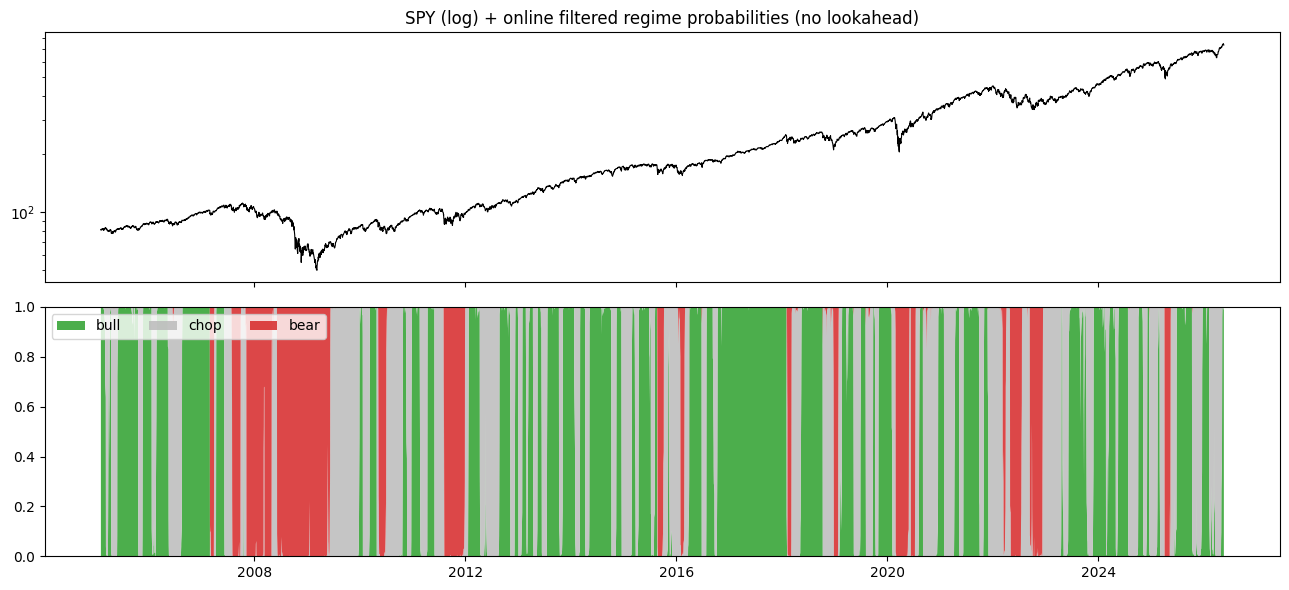

In [8]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
a1.plot(px.loc[filtered_probs.index], color='k', lw=0.8)
a1.set_yscale('log'); a1.set_title('SPY (log) + online filtered regime probabilities (no lookahead)')
a2.stackplot(filtered_probs.index,
              filtered_probs['bull'], filtered_probs['chop'], filtered_probs['bear'],
              labels=['bull', 'chop', 'bear'], colors=['#2ca02c', '#bbbbbb', '#d62728'], alpha=0.85)
a2.legend(loc='upper left', ncol=3); a2.set_ylim(0, 1)
plt.tight_layout()

## 5. Compare to the SMA-200 + vol mask

Replicate the current production mask (`ensemble_pipeline.py:222-230`) and stress both regimes against a SPY-only **regime-filtered buy-and-hold**: hold SPY when risk-on, cash otherwise.

Two HMM exposure variants:
- **Binary:** mask = (argmax state == bull)
- **Continuous:** exposure = P(bull) + 0.5 · P(chop)

All masks shifted by 1 day so today's mask uses only yesterday's info.

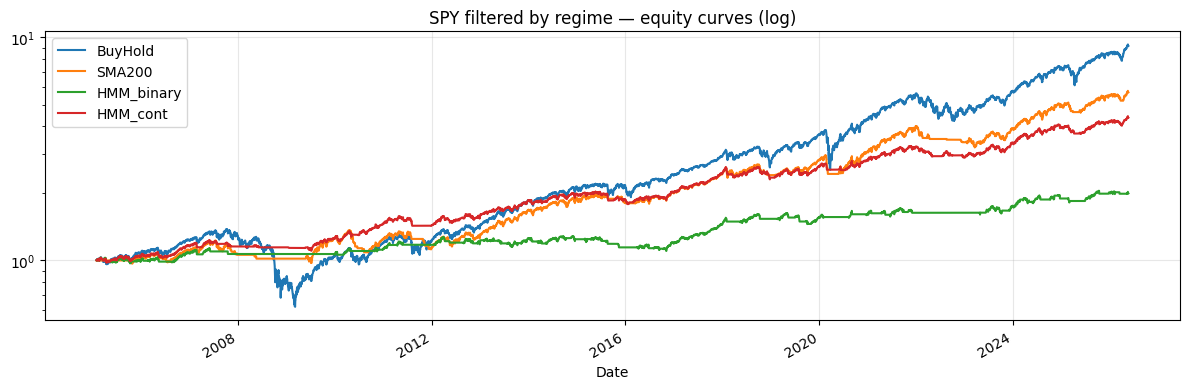

In [9]:
spy_sma200 = px.rolling(200).mean()
spy_dr = np.log(px / px.shift(1))
spy_avol = spy_dr.rolling(20).std() * np.sqrt(252)
sma_mask = ((px > spy_sma200) & (spy_avol < 0.35)).shift(1).astype(float)

hmm_binary = (filtered_probs.idxmax(axis=1) == 'bull').astype(float).shift(1)
hmm_cont = (filtered_probs['bull'] + 0.5 * filtered_probs['chop']).shift(1)

common = filtered_probs.index.intersection(sma_mask.dropna().index)
spy_ret = px.pct_change().reindex(common).fillna(0)

strategies = pd.DataFrame({
    'BuyHold':    spy_ret,
    'SMA200':     spy_ret * sma_mask.reindex(common).fillna(0),
    'HMM_binary': spy_ret * hmm_binary.reindex(common).fillna(0),
    'HMM_cont':   spy_ret * hmm_cont.reindex(common).fillna(0),
})
equity = (1 + strategies).cumprod()
equity.plot(logy=True, title='SPY filtered by regime — equity curves (log)')
plt.grid(True, alpha=0.3); plt.tight_layout()

In [10]:
def stats(r):
    r = r.dropna()
    ann = r.mean() * 252
    vol = r.std() * np.sqrt(252)
    sr = ann / vol if vol > 0 else np.nan
    eq = (1 + r).cumprod()
    dd = (eq / eq.cummax() - 1).min()
    return pd.Series({'ann_ret': ann, 'ann_vol': vol, 'sharpe': sr, 'max_dd': dd,
                       'exposure': (r != 0).mean()})

summary_tbl = strategies.apply(stats).T
summary_tbl.round(3)

,ann_ret,ann_vol,sharpe,max_dd,exposure
BuyHold,0.122,0.190,0.643,-0.552,0.997
SMA200,0.088,0.114,0.772,-0.207,0.766
HMM_binary,0.035,0.070,0.501,-0.142,0.431
HMM_cont,0.073,0.086,0.846,-0.122,0.995


### Regime overlap diagnostic

How often do the SMA and HMM regimes agree?

In [11]:
both = pd.concat({'sma': sma_mask, 'hmm': hmm_binary}, axis=1).dropna()
ct = pd.crosstab(both['sma'] > 0, both['hmm'] > 0, normalize=True)
ct.index.name = 'SMA risk-on'; ct.columns.name = 'HMM risk-on'
ct.round(3)

HMM risk-on,False,True
SMA risk-on,,
False,0.206,0.026
True,0.361,0.407


## 6. Next steps if results look promising

1. **Wire into the pipeline** — in `ensemble_pipeline.py` lines 222-230, replace `regime_mask_daily` with either the binary HMM mask or the continuous `P(bull) + 0.5*P(chop)` scalar. Keep the weekly resample to avoid trade churn.
2. **Persist the fitted model** between refits so production doesn't redo EM each call — save `pi, A, mu, sigma, mu_s, sd_s` per refit date to a pickle.
3. **Sensitivity checks:** try `n_states=2` and `n_states=4`, vary the realized-vol window (10 / 20 / 40), and try adding a third feature (e.g. drawdown-from-rolling-high or VIX).
4. **Stability:** the EM seed matters — run several seeds, pick the one with the highest train log-likelihood, OR average filtered probabilities across seeds.
5. **Backtest at the portfolio level**, not just SPY-only — re-run `ensemble_pipeline.py` with the HMM mask substituted in and compare Sharpe / max-DD against the SMA baseline on the full ensemble.